# Option 1 — Following the literature

Fixed low uncertainty with a wide stability window — the settled regime the published models operate in.

Parameter variant of `2. GColab Simulations Equality.ipynb`. Runs the Beta-agent (Bayesian)
bandit simulations on the **PUD**, **Tobacco** and **Ego depletion** citation networks
under density-preserving variation methods, so the manipulated dimension is degree
equality — never density.

| Method | Mechanism | Invariant | Runs by default |
|---|---|---|---|
| `equalize` | rewire *k* triangle edges toward degree equality | `|E|` fixed | yes |
| `randomization` | rewire *k* random edges (remove one / add one) | `|E|` fixed | no |

`METHODS` in `model/equality_study.py` defines both arms, but the config cell sets
`INCLUDE_RANDOMIZATION = False`, so **only `equalize` runs** unless you turn it on.
No arm manipulates clustering — those arms were removed from this study.

## What this study does differently

The design is **nested**. Rather than one simulation per parameter draw, it builds
`N_VARIANTS` distinct network variants per (network, method) cell and simulates each
one `N_RUNS` times under different seeds. Replicates of a variant share every
parameter and differ only in their simulation seed, which is what makes the
per-variant variance check meaningful: a variant whose replicates are identical
indicates a seeding fault, not agreement.

| Setting | Value |
|---|---|
| Uncertainty | `0.001` (fixed) |
| `n_experiments` | 1,000 |
| Max steps | 100,000 |
| Choice-stability window | 100 |
| Network variants per arm | 1,000 |
| `proportion_edges` | U(0, 0.1) |
| Runs per setting | 500 |

All machinery lives in `model/equality_study.py` so the three option notebooks
cannot drift apart. Everything is a pure function of `MASTER_SEED`: variant seeds
are keyed on (network, arm, variant index), so a session resuming at variant 457
rebuilds exactly the variant an earlier session would have built.

## Running this across sessions

A full run does not fit in one Colab session. `ACCUMULATE = True` (the default,
set in the first code cell) makes that a non-event: every variant is checkpointed
to its own shard as it finishes, and a later session skips what is already on
disk. Reconnect, re-run the notebook top to bottom, and it picks up where the
last one stopped.

To grow the study instead of merely finishing it, raise `N_VARIANTS` and re-run —
the new variants are appended and the existing ones are left untouched. The
status cell below reports where each arm stands before any compute is spent.

Outputs land in `Data Sets/equality_study/option1_literature/{smoke,full}/` as one shard
per variant, plus a per-variant summary table.

## Configuration

### Environment switch + master parameters

In [ ]:
MASTER_SEED     = 20260723
RUNNING_LOCALLY = True         # False → Colab: force-fresh clone, pip install, mount Drive.
                               # True → laptop, run from the repo clone (no clone/pip/Drive).
SMOKE_TEST      = True         # True → tiny grid (see note below)
ACCUMULATE      = True         # True → ADD to the results already on disk (see note below)
MAX_CORES = 8                  # Srhinks the number of cores (see note below)

Notes:

- ACCUMULATE is the multi-session switch, and a full run IS a multi-session job: no Colab runtime survives it in one sitting.
    - True (default) — this session's results are ADDED to whatever earlier sessions banked. Variants already on disk are skipped, so re-running after a disconnect resumes where it stopped rather than starting over. Raising N_VARIANTS between sessions is allowed and GROWS the study: 500 today and 1,000 tomorrow keeps the first 500 and adds 500..999. The seed sequences nest, so those first 500 are bit-identical to what the earlier session built — a grown grid extends the study rather than reinterpreting it.
    - False — start clean: DELETE this option's RUN_TAG subtree and regenerate from variant 0. The only path that discards data, and it has to be typed deliberately.
    - Editing a parameter that defines the study rather than its size (uncertainty, MASTER_SEED, MAX_STEPS, CS_WINDOW, N_RUNS, SMOKE_TEST) conflicts with what is already on disk. That now RAISES and deletes nothing; set ACCUMULATE = False if you genuinely want to throw the earlier run away.
- SMOKE_TEST shrinks the grid AND the step ceiling, so smoke numbers are NOT comparable with full-run numbers. Smoke exists to prove the plumbing — shard writes, resume, the variance check — not to measure anything. Smoke and full write to separate directories and carry different config fingerprints, so they can never be merged, but do not analyse a 'smoke' directory.
- MAX_CORES shrinks the total cores. Using all cores is too aggressive on a shared cloud runtime — each worker holds its own copy of the network plus simulation state, so memory, not CPU, is usually the binding constraint.

### Simulation parameters

In [8]:
# ══ Study configuration — the ONLY cell that differs between 2a / 2b / 2c ══
#
# Option 1 — Following the literature
#   Fixed low uncertainty with a wide stability window — the settled regime the published models operate in.

OPTION_SLUG  = 'option1_literature'
OPTION_TITLE = 'Option 1 — Following the literature'

UNCERTAINTY = 0.001    # fixed
CS_WINDOW   = 100             # choice-stability window
# N_RUNS is 500, not 1000, to match the variants already banked on Drive by
# earlier sessions. It is an IDENTITY key: raising it would make this session a
# different study, refuse to resume, and strand roughly two million completed
# simulations. Change it only alongside a new RUN_TAG (see the paths cell).
N_RUNS      = 500               # replicate runs per network variant

# ── Shared across all three options ──────────────────────────────────────────
N_EXPERIMENTS        = 1000
MAX_STEPS            = 100000
N_VARIANTS           = 1000   # 1000 here, not 500: pud and tobacco already
                              # hold 1000 variants each from earlier sessions,
                              # and the stamp on Drive records n_variants=1000.
CS_MIN_STEPS         = 0      # no floor: a floor suppresses the very window
                              # effect these options are set up to measure
PROPORTION_EDGES_MAX = 0.1    # the cap exists because `equalize` samples this
                              # many triangles and raises "Sample larger than
                              # population" beyond it

# Restrict this session to a bounded slice of variant indices so several
# machines can divide one arm without coordinating. None → take the whole arm.
VARIANT_SLICE = None          # e.g. (0, 250)

INCLUDE_RANDOMIZATION = False # True/False → include/exclude the randomization method in the study

# Setup

In [26]:
import os
import shutil
import subprocess
import sys
from pathlib import Path

In [10]:
# Force-fresh clone + deps (Colab only). Uses subprocess/os.chdir rather than
# !/% magics so the RUNNING_LOCALLY guard actually holds — a line magic fires
# regardless of the surrounding `if` (NOTEBOOK_WRITING_SKILL §5–6).
if not RUNNING_LOCALLY:
    # Anchor on an absolute base, never the cwd: resolving the repo name
    # relative to the cwd makes a second run clone INSIDE the first clone.
    COLAB_BASE = Path('/content')
    os.chdir(COLAB_BASE)
    repo_dir = COLAB_BASE / 'e_network_inequality'
    if repo_dir.exists():
        shutil.rmtree(repo_dir)
    subprocess.run(['git', 'clone', '-b', 'main',
                    'https://github.com/IgnacioOQ/e_network_inequality'], check=True)
    subprocess.run(['pip', 'install', '-q', 'dill'], check=True)
    os.chdir(repo_dir)
else:
    # This notebook lives at the repo root; walk up to the dir containing model/.
    PROJECT_ROOT = Path.cwd()
    while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'model').is_dir():
        PROJECT_ROOT = PROJECT_ROOT.parent
    os.chdir(PROJECT_ROOT)

sys.path.insert(0, os.getcwd())
print("Working dir:", os.getcwd())

Working dir: /Users/heinduijf/GitHub/e_network_inequality


In [11]:
# Explicit imports — no wildcards from external libraries (§4).
import pickle
from multiprocessing import cpu_count

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

# Internal package. Wildcards from our own modules are permitted, but naming
# what we use keeps the notebook readable and the dependency obvious.
from model.equality_study import (
    METHODS,
    SHARD_EXT,
    arm_dir,
    check_fingerprint,
    check_variance,
    parameter_coverage,
    plot_variant_summary,
    project_runtime,
    run_study,
    study_report,
    summarise_arm,
)
from utils.network_utils import network_statistics

print("Shard format:", SHARD_EXT)

Shard format: .parquet


/Users/heinduijf/GitHub/e_network_inequality/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
num_cores = min(cpu_count(), MAX_CORES)

if SMOKE_TEST:
    N_VARIANTS, N_RUNS, MAX_STEPS, CS_WINDOW = 3, 8, 2000, 50

SIM_KWARGS = dict(
    tolerance_stopping=False,
    choice_stability_stopping=True,
    choice_stability_window=CS_WINDOW,
    choice_stability_min_steps=CS_MIN_STEPS,
    record_choice_flips=False,
    number_of_steps=MAX_STEPS,
    show_bar=False,
    agent_type='beta',
)

_methods_to_run = list(METHODS) if INCLUDE_RANDOMIZATION else [m for m in METHODS if m != 'randomization']

_n_arms = len(_methods_to_run) * 3
print(f"{OPTION_TITLE}")
print(f"  uncertainty={UNCERTAINTY}  window={CS_WINDOW:,}  max_steps={MAX_STEPS:,}")
print(f"  {N_VARIANTS:,} variants x {N_RUNS:,} runs x {_n_arms} arms "
      f"= {N_VARIANTS * N_RUNS * _n_arms:,} model runs")


Option 1 — Following the literature
  uncertainty=0.001  window=50  max_steps=2,000
  3 variants x 8 runs x 3 arms = 72 model runs


In [13]:
# Output directory — one path constant per role, created once. Option and run
# tier each get their own tree, so no two configurations can share shards.
RUN_TAG = 'smoke' if SMOKE_TEST else 'full'
if RUNNING_LOCALLY:
    RESULTS_DIR = Path('results/equality_study') / OPTION_SLUG / RUN_TAG
else:
    from google.colab import drive
    drive.mount('/content/drive')
    RESULTS_DIR = (Path('/content/drive/My Drive/Colab Projects/Data Driven ABMs/'
                        'Data Sets/equality_study') / OPTION_SLUG / RUN_TAG)
RESULTS_DIR = Path(RESULTS_DIR)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print("Run tag:", RUN_TAG)
print("Results dir:", RESULTS_DIR)

# Deleting is handled by ACCUMULATE in the fingerprint cell below — one flag in
# one place, rather than a second delete path here that could disagree with it.
# The same scoping guard applies there: only ever a 'smoke'/'full' subtree.


def save_csv(df, name):
    path = RESULTS_DIR / name
    df.to_csv(path, index=False)
    print(f"  Saved: {path} ({len(df)} rows)")
    return path

Run tag: smoke
Results dir: results/equality_study/option1_literature/smoke


In [14]:
# Reconcile this session's configuration with the study already on disk.
#
# Identity keys (uncertainty, MASTER_SEED, MAX_STEPS, CS_WINDOW, N_RUNS,
# SMOKE_TEST, ...) must match what was stamped: a mismatch means these are two
# different studies, and merging them would build the summaries from one run's
# data under the other's label. A conflict RAISES and deletes nothing.
#
# Extent keys (N_VARIANTS, methods) may GROW, which is what makes ACCUMULATE
# work across sessions — see the note in the env-switch cell.
CONFIG = dict(
    option=OPTION_SLUG,
    master_seed=MASTER_SEED,
    smoke=bool(SMOKE_TEST),
    uncertainty=UNCERTAINTY,
    n_experiments=N_EXPERIMENTS,
    max_steps=MAX_STEPS,
    window=CS_WINDOW,
    min_steps=CS_MIN_STEPS,
    n_variants=N_VARIANTS,
    n_runs=N_RUNS,
    proportion_edges_max=PROPORTION_EDGES_MAX,
    methods=_methods_to_run,
    skip_arms=[],
)
check_fingerprint(RESULTS_DIR, CONFIG, accumulate=ACCUMULATE)

  New study — configuration stamped.


{'schema': 1,
 'master_seed': 20260723,
 'max_steps': 2000,
 'methods': ['equalize'],
 'min_steps': 0,
 'n_experiments': 1000,
 'n_runs': 8,
 'n_variants': 3,
 'option': 'option1_literature',
 'proportion_edges_max': 0.1,
 'skip_arms': [],
 'smoke': True,
 'uncertainty': 0.001,
 'window': 50}

# Load networks

In [15]:
def load_indexed(path):
    """Load a pickled citation network, relabelled to contiguous integer indices.

    The vectorized model indexes its adjacency matrix positionally, so node
    labels must be 0..n-1.
    """
    with open(path, 'rb') as f:
        G = pickle.load(f)
    G = nx.relabel_nodes(G, {n: i for i, n in enumerate(G.nodes())})
    assert not list(nx.selfloop_edges(G)), f"self-loops present in {path}"
    print(f"  {os.path.basename(path)}: {G.number_of_nodes()} nodes, "
          f"{G.number_of_edges()} edges, "
          f"avg clustering {nx.average_clustering(G):.5f}")
    return G


print("Loading networks:")
NETWORKS = [
    ('pud',     load_indexed('./networks/citation_data/pud_network.pkl')),
    ('tobacco', load_indexed('./networks/citation_data/tobacco_network.pkl')),
    ('ego',     load_indexed('./networks/citation_data/ego_network.pkl')),
]

Loading networks:
  pud_network.pkl: 90 nodes, 160 edges, avg clustering 0.16391
  tobacco_network.pkl: 289 nodes, 1229 edges, avg clustering 0.23497
  ego_network.pkl: 503 nodes, 2933 edges, avg clustering 0.59374


In [16]:
# Baseline structure of each unmodified network — the reference point every
# variant's equality and clustering statistics are read against.
baseline = pd.DataFrame([
    {'network': label,
     'n_nodes': G.number_of_nodes(),
     'n_edges': G.number_of_edges(),
     **{k: float(v) for k, v in network_statistics(G).items()}}
    for label, G in NETWORKS
])
save_csv(baseline, 'baseline_network_statistics.csv')
baseline

  Saved: results/equality_study/option1_literature/smoke/baseline_network_statistics.csv (3 rows)


,network,n_nodes,n_edges,average_degree,degree_gini_coefficient,approx_average_clustering_coefficient
0,pud,90,160,1.777778,0.724583,0.163907
1,tobacco,289,1229,4.252595,0.761313,0.234973
2,ego,503,2933,5.831014,0.920430,0.593740


# Progress report

Where the study stands before this session spends any compute: how many
simulations are banked against the goal, how much is left, whether it is
finished, and which parameter settings are already covered.

Both cells read directory listings and each arm's small `cost.csv` — never the
shards — so they stay instant on a finished study holding millions of rows, and
cost almost nothing across the Colab Drive mount.

In [17]:
# Safe to run at any point: a fresh study reports zero for every arm.
REPORT = study_report(RESULTS_DIR, NETWORKS, _methods_to_run, N_VARIANTS, N_RUNS)
REPORT

Progress report — results/equality_study/option1_literature/smoke
  0 / 72 simulations  (0.0% of goal)
  0 / 9 variants   |   arms complete: 0/3
  [........................................]
  STATUS: IN PROGRESS — no timing data yet (no variant has finished).


,network,method,variants_done,variants_target,sims_done,sims_target,pct_complete,variants_left,sims_left,beyond_target,sec_per_variant,hours_left,status
0,pud,equalize,0,3,0,24,0.0,3,24,0,NaN,NaN,not started
1,tobacco,equalize,0,3,0,24,0.0,3,24,0,NaN,NaN,not started
2,ego,equalize,0,3,0,24,0.0,3,24,0,NaN,NaN,not started


In [18]:
# Which parameter settings are banked, and which are still pending.
#
# Derived from the seed sequences rather than from the shards: build_setting
# draws a variant's parameters BEFORE it builds the (expensive) network, so a
# pending variant's settings are knowable without paying to construct it. The
# table therefore covers the whole grid, not just the finished part — a session
# that stopped halfway, or a VARIANT_SLICE claimed by another machine, leaves
# gaps that a bare count of completed variants would hide.
COVERAGE = parameter_coverage(
    RESULTS_DIR, NETWORKS, _methods_to_run, N_VARIANTS,
    master_seed=MASTER_SEED,
    uncertainty=UNCERTAINTY,
    n_runs=N_RUNS,
    proportion_edges_max=PROPORTION_EDGES_MAX,
)
COVERAGE.head()

Parameter coverage — 0 of 9 planned variants banked
  proportion_edges: planned [0.00574196, 0.0929249]
    banked: none yet
  9 pending; next index per arm: ego/equalize=0, pud/equalize=0, tobacco/equalize=0


,network,method,variant_index,variation_seed,uncertainty,proportion_edges,done
0,pud,equalize,0,2165121741,0.001,0.043796,False
1,pud,equalize,1,2310751638,0.001,0.076242,False
2,pud,equalize,2,3085228320,0.001,0.041684,False
3,tobacco,equalize,0,1183105679,0.001,0.052071,False
4,tobacco,equalize,1,4189262771,0.001,0.020074,False


# Run the study

One shard per network variant, written atomically. Interrupting this cell loses at
most the variant in flight; re-running skips every variant already on disk, so a
Colab disconnect costs minutes rather than the whole run.

At full scale this cell is a multi-day job. Use `VARIANT_SLICE` in the config cell
to claim a bounded range of variant indices so several machines can share an arm.

In [19]:
%%time
# Nested design: N_VARIANTS distinct variants per (network, arm), each simulated
# N_RUNS times under different seeds. The variant is handed to the worker pool
# once via its initializer rather than riding in every job's parameter dict —
# at 1,000 replicates that is the difference between pickling the graph once per
# worker and once per run.
cost = run_study(
    NETWORKS,
    RESULTS_DIR,
    methods=_methods_to_run,
    skip=[],
    master_seed=MASTER_SEED,
    n_variants=N_VARIANTS,
    n_runs=N_RUNS,
    uncertainty=UNCERTAINTY,
    n_experiments=N_EXPERIMENTS,
    sim_kwargs=SIM_KWARGS,
    num_cores=num_cores,
    variant_slice=VARIANT_SLICE,
    build_kwargs=dict(proportion_edges_max=PROPORTION_EDGES_MAX),
)
save_csv(cost, 'cost_all_arms.csv')

  [pud/equalize] 3 variants requested, 0 already on disk, 3 to run (24 simulations)


[pud/equalize]: 100%|██████████| 3/3 [00:02<00:00,  1.14variant/s, build=0.0s, run=0.8s]


  [tobacco/equalize] 3 variants requested, 0 already on disk, 3 to run (24 simulations)


[tobacco/equalize]: 100%|██████████| 3/3 [00:03<00:00,  1.02s/variant, build=0.2s, run=0.9s]


  [ego/equalize] 3 variants requested, 0 already on disk, 3 to run (24 simulations)


[ego/equalize]: 100%|██████████| 3/3 [00:08<00:00,  2.93s/variant, build=3.7s, run=0.9s]

  Saved: results/equality_study/option1_literature/smoke/cost_all_arms.csv (9 rows)
CPU times: user 6.72 s, sys: 363 ms, total: 7.09 s
Wall time: 14.5 s


PosixPath('results/equality_study/option1_literature/smoke/cost_all_arms.csv')

# Session result

Where this session ended, re-read from disk so it reflects what was actually
written rather than what the run cell believed it wrote. Both tables are saved
next to the shards, so the record of what is done — and under which parameters —
survives the runtime being released.

In [20]:
REPORT = study_report(RESULTS_DIR, NETWORKS, _methods_to_run, N_VARIANTS, N_RUNS)
save_csv(REPORT, 'progress_report.csv')

COVERAGE = parameter_coverage(
    RESULTS_DIR, NETWORKS, _methods_to_run, N_VARIANTS,
    master_seed=MASTER_SEED,
    uncertainty=UNCERTAINTY,
    n_runs=N_RUNS,
    proportion_edges_max=PROPORTION_EDGES_MAX,
)
save_csv(COVERAGE, 'parameter_coverage.csv')

REPORT

Progress report — results/equality_study/option1_literature/smoke
  72 / 72 simulations  (100.0% of goal)
  9 / 9 variants   |   arms complete: 3/3
  [########################################]
  STATUS: DONE — every arm has reached n_variants.
  Saved: results/equality_study/option1_literature/smoke/progress_report.csv (3 rows)
Parameter coverage — 9 of 9 planned variants banked
  proportion_edges: planned [0.00574196, 0.0929249]
    banked [0.00574196, 0.0929249]  quartile occupancy [2, 2, 3, 2]
  Saved: results/equality_study/option1_literature/smoke/parameter_coverage.csv (9 rows)


,network,method,variants_done,variants_target,sims_done,sims_target,pct_complete,variants_left,sims_left,beyond_target,sec_per_variant,hours_left,status
0,pud,equalize,3,3,24,24,100.0,0,0,0,0.9,0.0,complete
1,tobacco,equalize,3,3,24,24,100.0,0,0,0,1.0,0.0,complete
2,ego,equalize,3,3,24,24,100.0,0,0,0,2.9,0.0,complete


# Validation — seeding and variance

For every variant: are its replicate seeds all distinct, and does at least one
outcome actually vary across them?

A variant whose replicates are identical is the signature of the fork-inherited-RNG
bug — every worker drawing the same stream. It presents as unanimous agreement and
zero variance rather than as a crash, which is why it needs an explicit check rather
than trust.

In [21]:
_skip = set()
reports = []
for label, _ in NETWORKS:
    for method in _methods_to_run:
        if (label, method) in _skip:
            continue
        rep = check_variance(arm_dir(RESULTS_DIR, label, method))
        if len(rep):
            rep.insert(0, 'method', method)
            rep.insert(0, 'network', label)
            reports.append(rep)

variance_report = pd.concat(reports, ignore_index=True) if reports else pd.DataFrame()
if len(variance_report):
    save_csv(variance_report, 'variance_check.csv')
    n_bad = int((~variance_report['seeds_distinct']).sum()
                + (~variance_report['any_variance']).sum())
    verdict = 'PASS' if n_bad == 0 else 'FAIL'
    print(f"\n{verdict} — {n_bad} problem variant(s) of {len(variance_report)} checked")
else:
    print("No shards yet — run the study cell first.")

  [pud_equalize] 3 variants x 8 replicates
  [pud_equalize] OK — seeds distinct and every variant varies across replicates
  [tobacco_equalize] 3 variants x 8 replicates
  [tobacco_equalize] OK — seeds distinct and every variant varies across replicates
  [ego_equalize] 3 variants x 8 replicates
  [ego_equalize] OK — seeds distinct and every variant varies across replicates
  Saved: results/equality_study/option1_literature/smoke/variance_check.csv (9 rows)

PASS — 0 problem variant(s) of 9 checked


# Per-variant summaries

One row per variant: its structural covariates plus mean and standard deviation
across replicates. This is the analysis-facing table — a finished option holds well
over a million replicate rows but only a few thousand variant rows, and the variant
is the unit at which the equality covariates actually vary.

Saved twice: `variant_summary.csv` combining every arm, and one
`variant_summary_<network>.csv` per network. Reading the shards is the one
expensive operation in this notebook — every replicate row crosses the Drive
mount — so it happens once here and both forms are written from the result.

In [22]:
summaries = []
for label, _ in NETWORKS:
    for method in _methods_to_run:
        if (label, method) in _skip:
            continue
        s = summarise_arm(arm_dir(RESULTS_DIR, label, method))
        if len(s):
            summaries.append(s)

summary = pd.concat(summaries, ignore_index=True) if summaries else pd.DataFrame()
if len(summary):
    save_csv(summary, 'variant_summary.csv')
    # One CSV per network beside the combined table. The combined file stays the
    # analysis input; these exist so a single network can be read — or handed to
    # a collaborator — without loading the other two. Sliced from the same frame,
    # so they cannot drift from it. A network with no shards yet is skipped
    # rather than written empty, which keeps a partial study readable: a missing
    # file means "not started", not "zero results".
    for label, _ in NETWORKS:
        sub = summary[summary['network'] == label]
        if len(sub):
            save_csv(sub, f'variant_summary_{label}.csv')

summary.head()

  Saved: results/equality_study/option1_literature/smoke/variant_summary.csv (9 rows)
  Saved: results/equality_study/option1_literature/smoke/variant_summary_pud.csv (3 rows)
  Saved: results/equality_study/option1_literature/smoke/variant_summary_tobacco.csv (3 rows)
  Saved: results/equality_study/option1_literature/smoke/variant_summary_ego.csv (3 rows)


,network,method,variant_index,proportion_edges,uncertainty,n_experiments,n_agents,n_edges,average_degree,degree_gini_coefficient,approx_average_clustering_coefficient,variation_seed,mean_share_of_correct_agents_at_convergence,std_share_of_correct_agents_at_convergence,mean_convergence_step,std_convergence_step,mean_proportion_reached_by_truth,std_proportion_reached_by_truth,n_runs
0,pud,equalize,0,0.043796,0.001,1000,90,160,1.777778,0.702778,0.170759,2165121741,0.680556,0.082882,706.000,372.871483,0.675000,0.093859,8
1,pud,equalize,1,0.076242,0.001,1000,90,160,1.777778,0.686667,0.165283,2310751638,0.731944,0.116601,636.875,292.313158,0.705556,0.091045,8
2,pud,equalize,2,0.041684,0.001,1000,90,160,1.777778,0.708333,0.165682,3085228320,0.790278,0.075695,731.375,196.169706,0.779167,0.098209,8
3,tobacco,equalize,0,0.052071,0.001,1000,289,1229,4.252595,0.742067,0.235293,1183105679,0.900087,0.020961,1021.875,247.727637,0.900087,0.018069,8
4,tobacco,equalize,1,0.020074,0.001,1000,289,1229,4.252595,0.753250,0.235143,4189262771,0.892301,0.020043,1220.875,375.851581,0.897924,0.020843,8


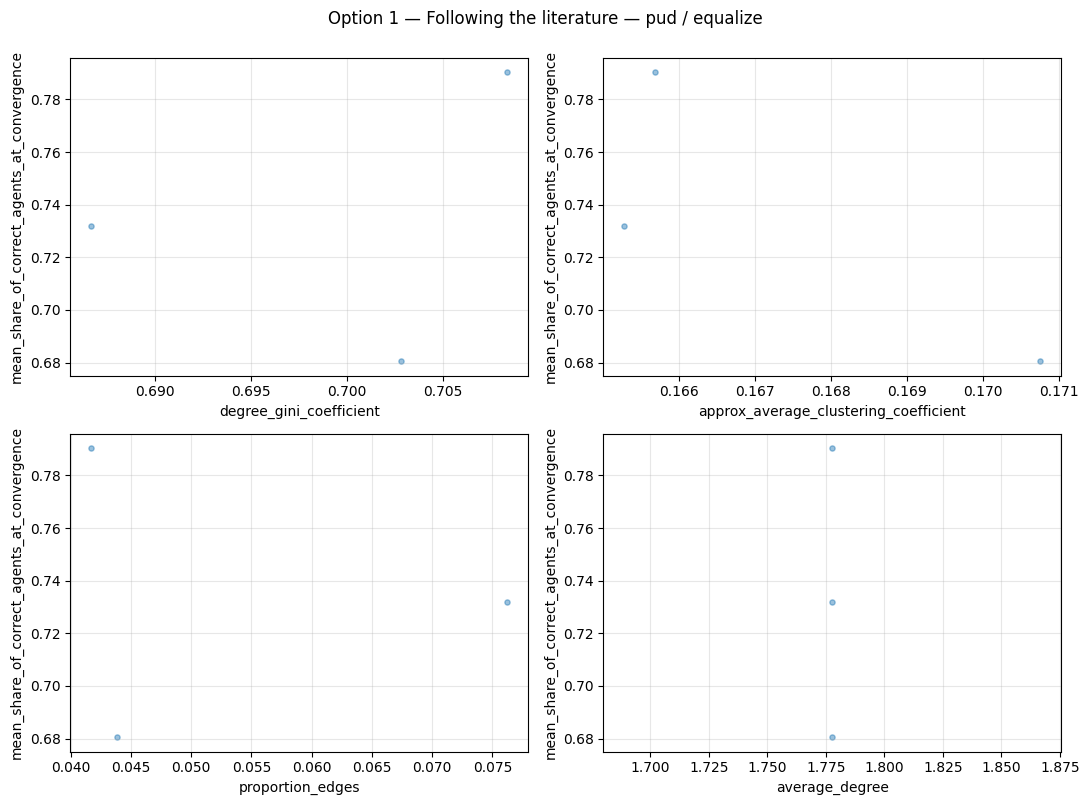

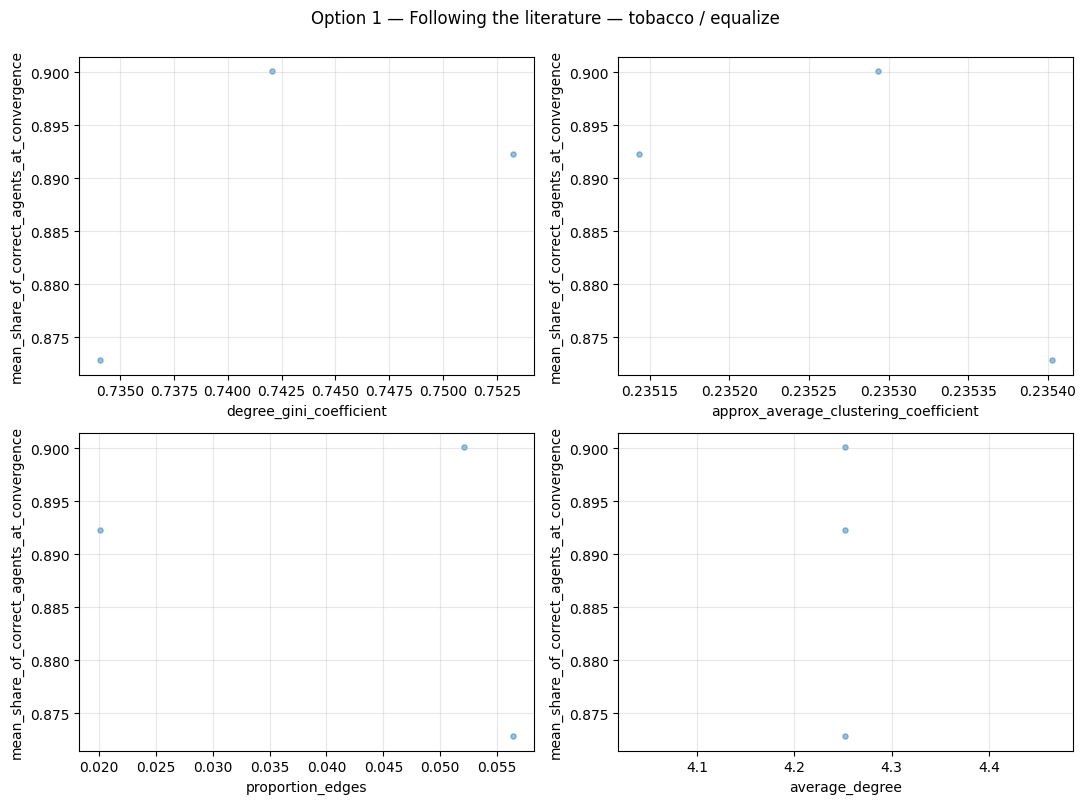

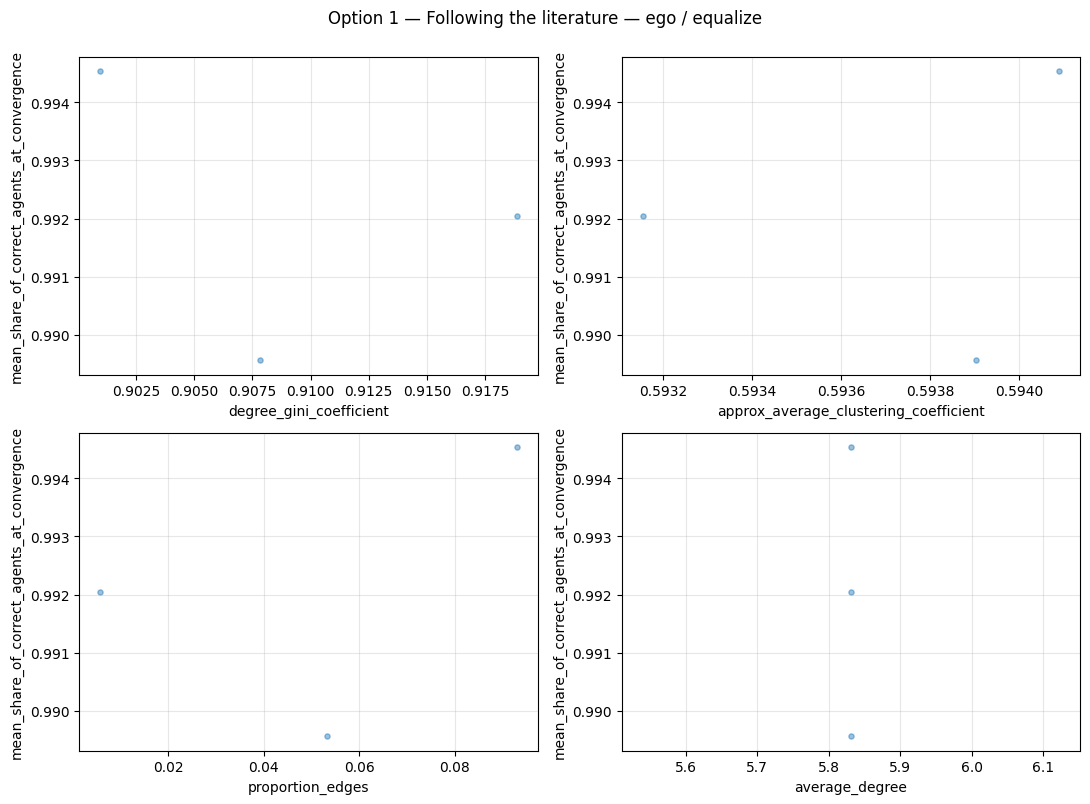

In [23]:
# One point per variant: its mean outcome against each structural predictor.
# Deliberately not utils.network_utils.scatter_plot, which plots every numeric
# column and would here include seeds and indices.
for label, _ in NETWORKS:
    for method in _methods_to_run:
        if (label, method) in _skip or not len(summary):
            continue
        sub = summary[(summary['network'] == label) & (summary['method'] == method)]
        if not len(sub):
            continue
        plot_variant_summary(
            sub,
            title=f"{OPTION_TITLE} — {label} / {method}",
            save_path=RESULTS_DIR / f"{label}_{method}_scatter.png",
        )

# Runtime projection

Extrapolates the remaining wall-clock from the variants completed so far. At full
scale this is the number that decides whether to partition an arm across machines
with `VARIANT_SLICE`.

In [24]:
if 'cost' in dir() and len(cost):
    projection = project_runtime(cost, N_VARIANTS, N_RUNS)
    save_csv(projection, 'runtime_projection.csv')
    display(projection)
else:
    print("No cost data yet — run the study cell first.")

  Saved: results/equality_study/option1_literature/smoke/runtime_projection.csv (3 rows)


,network,method,variants_done,mean_build_sec,mean_run_sec,sec_per_run,variants_left,projected_hours_left,projected_total_hours
0,ego,equalize,3,2.052968,0.869364,0.108671,0,0.0,0.002435
1,pud,equalize,3,0.006221,0.856756,0.107094,0,0.0,0.000719
2,tobacco,equalize,3,0.166030,0.849879,0.106235,0,0.0,0.000847


# Disconnect from runtime

In [25]:
# Must be the LAST cell — after every save. `runtime.unassign()` actually frees
# the runtime, whereas `kernel.disconnect()` only detaches the frontend and
# leaves it assigned (and billed). Gated so a developer iterating interactively
# is not kicked out (NOTEBOOK_WRITING_SKILL §11).
AUTO_DISCONNECT = True

if AUTO_DISCONNECT and not RUNNING_LOCALLY:
    from datetime import datetime
    import pytz
    stamp = datetime.now(pytz.timezone('America/New_York')).strftime('%Y-%m-%d %H:%M:%S %Z')
    print(f"Finished at {stamp} — releasing runtime.")
    from google.colab import runtime
    runtime.unassign()
else:
    print("Run complete (runtime not released; set AUTO_DISCONNECT=True to free it).")

Run complete (runtime not released; set AUTO_DISCONNECT=True to free it).
